In [1]:
using Pkg
Pkg.activate(".")
Pkg.add(["Polyhedra", "CDDLib", "Plots", "HiGHS", "NEOSServer", "JuMP"])
Pkg.instantiate()
include("Polyhedron.jl")
using .Poly

  Activating project at `~/Documents/AreaDeTrabalho/mo vei/conj invariantes/Polyhedron`
   Resolving package versions...
  No Changes to `~/Documents/AreaDeTrabalho/mo vei/conj invariantes/Polyhedron/Project.toml`
  No Changes to `~/Documents/AreaDeTrabalho/mo vei/conj invariantes/Polyhedron/Manifest.toml`
┌ Warning: Make sure you comply with the NEOS terms of use: http://www.neos-server.org/neos/termofuse.html
└ @ NEOSServer ~/.julia/packages/NEOSServer/2P7PD/src/NEOSServer.jl:14


In [2]:
# copie e cole os seus parâmetros

A = [0.9666 0;
    0.0328 0.9666] 
B = [0.1980;
    0.0033;;]

C = [0 1]

t = 0.5

delta = 0.8

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -t 1 t; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/15 0
      0 1/15;
     -1/15 0;
      0 -1/15;]
Sv = [1/300;
      -1/300;]

Sw = [1/50;
      -1/50;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

V = [1/4;
     -1/4;]

# Fr para a referência
R = [1/15;
      -1/15;;]
d = 2

2

declarar as variáveis para o sistema de tanques com atraso d = 2, delta = 0.8

In [5]:
result_1 = Poly.finding_L_pinvariant_segref_delay_sim2(A_exp, B_exp, E_exp, S, R, V, d, lambda=0.999, lf=24, time=60)

Job 18741228 dispatched
password: NvJTjibC
---------- Begin Solver Output -----------

Condor submit: 'neos.submit'
Condor submit: 'watchdog.submit'
Job submitted to NEOS HTCondor pool.

OTHER_LIMIT

Dict{String, Matrix{Float64}} with 36 entries:
  "P_diff" => [-0.00288969 0.00288969; -0.00485269 0.00485269; … ; -0.00271332 …
  "Zm"     => [17.404 17.4183 … 17.6578 17.6124; 17.7938 17.8822 … 17.6639 17.5…
  "P_sum"  => [0.0137629 0.0137629; 0.00847614 0.00847614; … ; 0.0104323 0.0104…
  "U_sum"  => [0.00404339 0.003088 … 0.00441365 0.00348909; 0.00404339 0.003088…
  "Um"     => [0.00391839 0.00190723 … 0.00439443 0.00346065; 0.000124999 0.001…
  "Zp"     => [17.7467 17.8015 … 17.6125 17.6634; 17.2616 17.2991 … 17.583 17.6…
  "M_diff" => [-0.00012171 7.14959e-7 … -1.76196e-5 -2.77742e-5; 0.000185725 2.…
  "Hp"     => [0.0110182 0.000315347 … 0.00235554 0.00419269; 0.000468162 0.007…
  "Tp"     => [0.0220573 0.00363623 … 0.00482547 0.00740121; 9.87603e-7 5.86181…
  "Z_sum"  => [35.1507 35.2198 … 35.2703 35.2758; 35.0554 35.1813 … 35.2469 35.…
  "H_diff" => [0.00973929 -0.00599728 … -0.000560535 0.00287365; -0.0119153 0.0…
  "Mm"     => [0.00121359 0.00114864 … 0.00115785 0.00116303; 

In [6]:
using LinearAlgebra

F = result_1["F"]
F = vcat(F, -F)

48×4 Matrix{Float64}:
  0.045404      0.0515447    -0.00139983   -0.00192646
 -0.0710123    -0.0776074     0.00323182   -0.00323513
 -0.0235135    -0.0213211    -0.000171865   0.000902045
  9.64363e-5    8.13458e-5    0.00332982    1.43303e-7
  0.00109366   -6.26702e-5   -0.000110974  -6.76132e-5
  0.00133699   -0.000828256   4.99865e-5   -0.000504497
 -0.0214255    -0.0274113    -6.2709e-5     0.0014484
 -0.00538323   -0.00388835    0.000133744   0.000601556
 -0.0515756    -0.135573      0.00402684    0.000599617
 -0.154499     -0.131792      0.00678354    0.0432833
  0.0523937     0.122024     -0.00382884   -0.00046226
 -0.061785     -0.0598549     0.001849      0.0011184
  0.00366508    0.00496092   -0.000126907   0.000511132
  ⋮                                        
 -0.00366508   -0.00496092    0.000126907  -0.000511132
  0.000815799  -0.0430765     0.00126022    0.0501997
 -0.0365726    -0.0394616     0.00147727    0.000232995
 -0.0287628    -0.0241427     0.000855655  -0.00052

In [7]:
G = result_1["G"]

1×4 Matrix{Float64}:
 -0.902673  -0.765538  0.0391188  0.103569

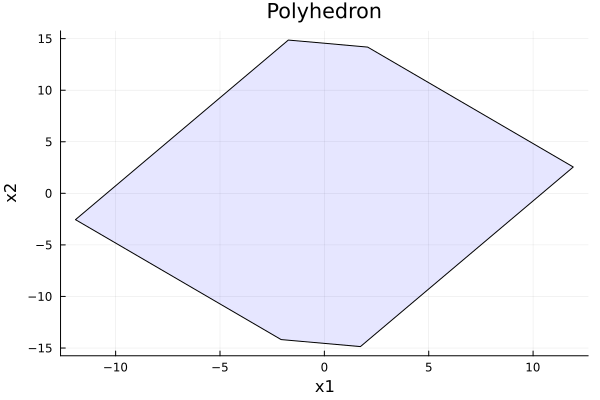

In [8]:
T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

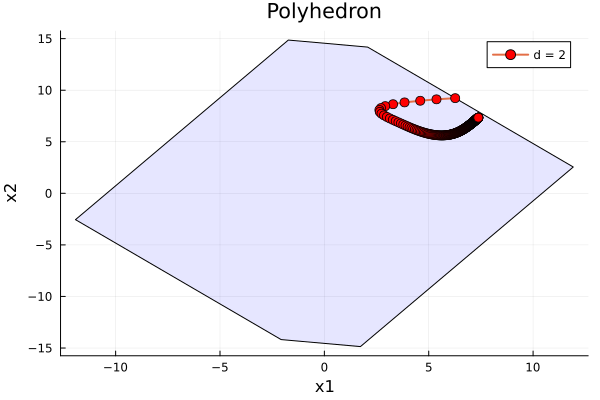

In [11]:
using Plots

w = ones(size(F, 1))
nx = size(A_exp, 1)

passos = 300
r = ones(passos)*7.4 # escolher a referência a se seguir 

BG = B_exp * G

init_cond_F, init_cond_w = Poly.admissable_initCond(A_exp, BG, F, d, w; fixed_d=true)
ext_vertices_tuple = Poly.get_extVert_tuple(init_cond_F, init_cond_w, 3, nx)
traj = Poly.trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=false)

Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

x1 = [p[1] for p in traj]
x2 = [p[2] for p in traj]
v = [p[3] for p in traj]
w = [p[4] for p in traj]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 2",
     xlabel = "x1",
     ylabel = "x2")

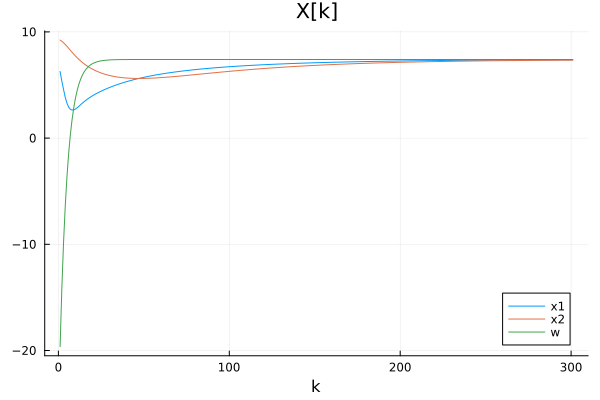

In [12]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

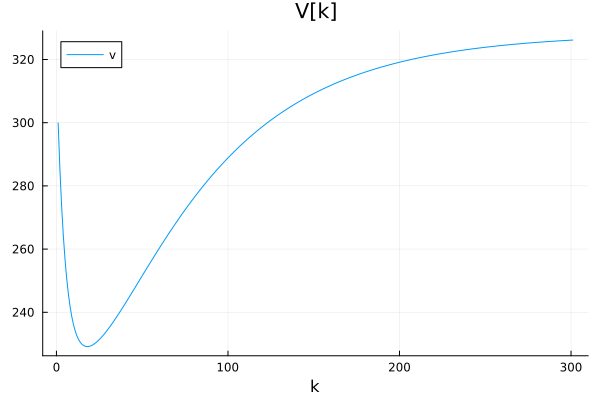

In [13]:
plot(v,
     label="v",
     xlabel="k",
     title="V[k]")

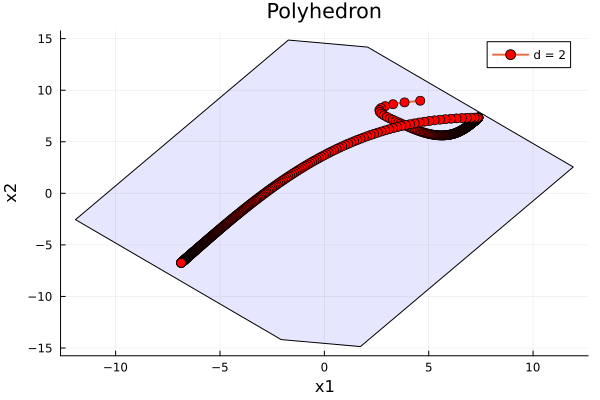

In [14]:
r = ones(passos) * -7

traj2 =Poly.trajectory_segref_delay(traj, A_exp, BG, E_exp, r, passos, d; reverse=false)
Poly.plot_poly(T*F[:,1:2], T*ones(size(F, 1)))

x1 = [p[1] for p in traj2]
x2 = [p[2] for p in traj2]
v = [p[3] for p in traj2]
w = [p[4] for p in traj2]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 2",
     xlabel = "x1",
     ylabel = "x2")

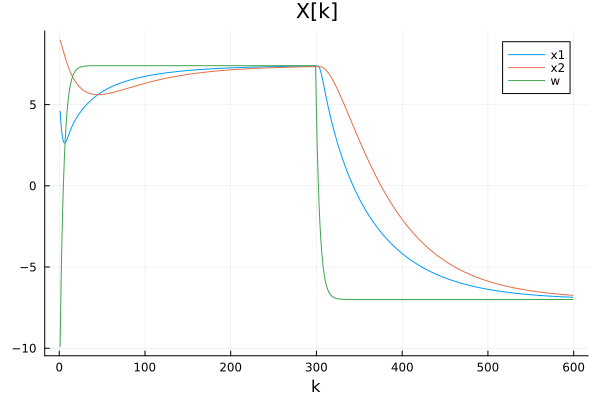

In [15]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

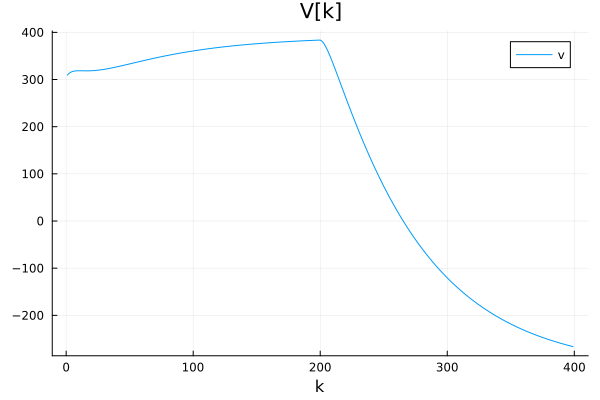

In [56]:
plot(v,
     label="v",
     xlabel="k",
     title="V[k]")

Computed u for traj; length = 301


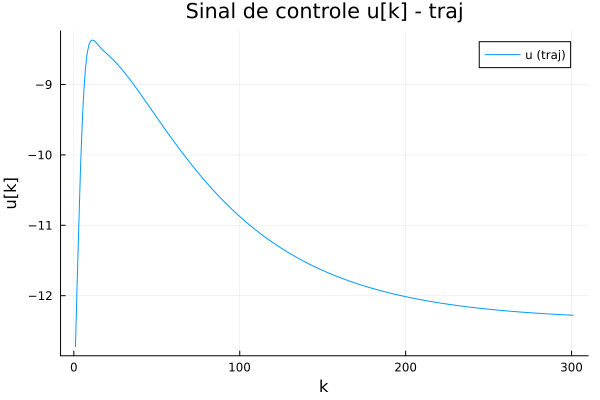

In [16]:
# Cálculo simples do sinal de controle usando `Gx = G[:, 1:2]`
using Plots

# Use as duas primeiras colunas de G
Gx = G[:, 1:2]

# Calcular u para `traj` (assume que `traj` existe)
u = [(Gx * [p[1]; p[2]])[1] for p in traj]
println("Computed u for traj; length = ", length(u))
plot(u, label = "u (traj)", xlabel = "k", ylabel = "u[k]", title = "Sinal de controle u[k] - traj")

Computed u2 for traj2; length = 599


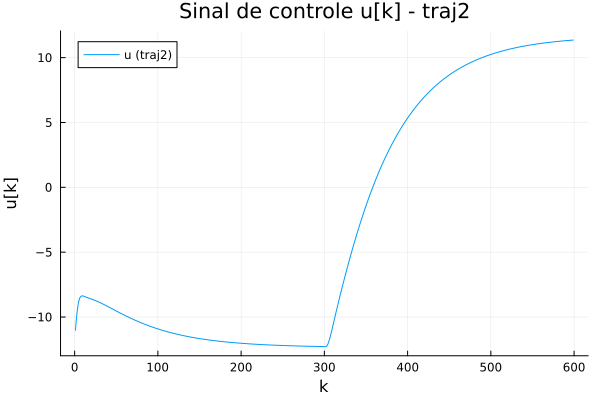

In [17]:
# Calcular u2 para `traj2` (assume que `traj2` existe)
u2 = [(Gx * [p[1]; p[2]])[1] for p in traj2]
println("Computed u2 for traj2; length = ", length(u2))
plot(u2, label = "u (traj2)", xlabel = "k", ylabel = "u[k]", title = "Sinal de controle u[k] - traj2")
